In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from Constants import Const
import SymptomPreprocessing as Symptom
import re

In [2]:
%load_ext autoreload
%autoreload 2

In [44]:
map1_path = '../Anonymized_DVH_Values____to_be_shared/PatientIDs_merged_Anonymized_INCLUDING_STIEFEL_IDs.xlsx'
map2_path = '../Anonymized_DVH_Values____to_be_shared-for__Batch_10/PatientIDs_Anonymized_INCLUDING_STIEFEL_IDs.xlsx'
stiefel_map_path = '../Cohort_SMART2_530pts_(486pts) - STIEFEL_ID_Anonymized_20260421.xlsx'

map1 = pd.read_excel(map1_path)
map2 = pd.read_excel(map2_path)

print('map1 shape:', map1.shape, 'map2 shape:', map2.shape)

# --- Validate that Stiefel IDs exist in BOTH sources (map1+map2 vs stiefel_map) ---
strict = True  # set False to only print warnings

stiefel_map = pd.read_excel(stiefel_map_path)

def _find_column(df: pd.DataFrame, candidates):
    cols_lower = {c.lower(): c for c in df.columns}
    for cand in candidates:
        if cand.lower() in cols_lower:
            return cols_lower[cand.lower()]
    raise KeyError(f"None of {candidates} found in columns: {list(df.columns)}")

def _normalize_stiefel_ids(series: pd.Series) -> pd.Series:
    s = series.dropna().astype(str).str.strip()
    s = s.replace({'': np.nan, 'nan': np.nan, 'None': np.nan}).dropna()
    # If Excel typed an ID column as numeric, it often becomes '12345.0'
    numeric_like = s.str.fullmatch(r"\d+(\.0)?")
    if numeric_like.any():
        s.loc[numeric_like] = (
            pd.to_numeric(s.loc[numeric_like], errors='coerce')
            .dropna()
            .astype(int)
            .astype(str)
        )
    # Case-normalize for robust matching
    return s.str.upper()

map_stiefel_col = _find_column(map1, ['STIEFEL_ID', 'Stiefel_ID'])
stiefel_col = _find_column(stiefel_map, ['Stiefel_ID', 'STIEFEL_ID'])

map_ids = pd.concat([map1[map_stiefel_col], map2[map_stiefel_col]], ignore_index=True)
map_ids = _normalize_stiefel_ids(map_ids)
stiefel_ids = _normalize_stiefel_ids(stiefel_map[stiefel_col])

map_set = set(map_ids.unique())
stiefel_set = set(stiefel_ids.unique())

only_in_map = sorted(map_set - stiefel_set)
only_in_stiefel = sorted(stiefel_set - map_set)

print('unique STIEFEL_IDs in map1+map2:', len(map_set))
print('unique Stiefel_IDs in stiefel_map:', len(stiefel_set))
print('IDs in map1+map2 but NOT in stiefel_map:', len(only_in_map))
print('IDs in stiefel_map but NOT in map1+map2:', len(only_in_stiefel))
if len(only_in_map) > 0:
    print('Example only_in_map:', only_in_map[:10])
if len(only_in_stiefel) > 0:
    print('Example only_in_stiefel:', only_in_stiefel[:10])

if strict and (len(only_in_map) > 0 or len(only_in_stiefel) > 0):
    raise ValueError(
        'Stiefel_ID mismatch between mapping spreadsheets and stiefel_map. '
        f'only_in_map={len(only_in_map)}, only_in_stiefel={len(only_in_stiefel)}'
    )

map1 shape: (435, 2) map2 shape: (51, 2)
unique STIEFEL_IDs in map1+map2: 486
unique Stiefel_IDs in stiefel_map: 486
IDs in map1+map2 but NOT in stiefel_map: 0
IDs in stiefel_map but NOT in map1+map2: 0


In [48]:
#preface: the goal of this part is to do the preprocessing to get the data needed for the clustering
temp = pd.read_csv(Const.data_dir+'minimal_dose_cluster_dataset.csv')
#the version I use has a bunch of optional preprocessing stuff
#main things: id, dose values ("DX" or "VX"), demographics + treatment info, and symptoms (symptoms_<name>)
#included in this exampe is also non-imputed symptoms (symptoms_<name>_original), and experimental symptom groups which will not be done in this notebook code example
for col in temp.columns:
    #skip similar values for the symptoms ect
    if 'symptoms' in col and 'drymouth' not in col:
        continue
    if len(col) == 3 and col[0] in ['V','D']:
        continue
    print(col,temp[col].iloc[0])
    print()

id 2

D2 [54.53125, 28.1875, 59.84375, 57.40625, 55.9375, 63.71875, 56.125, 73.1875, 26.53125, 70.375, 71.0625, 60.875, 55.90625, 56.125, 63.46875, 43.90625, 36.6875, 72.5625, 58.84375, 67.8125, 72.375, 73.0, 61.5, 60.875, 73.0625, 72.875, 64.9375, 72.5625, 73.1875, 72.375, 72.625, 58.90625, 72.375, 72.1875, 72.5625, 71.875, 52.875, 35.5625, 20.453125, 48.5625]

D5 [53.21875, 27.4375, 58.28125, 55.5, 54.90625, 60.875, 53.3125, 73.0, 24.875, 62.65625, 69.875, 60.5, 55.71875, 52.53125, 60.84375, 38.21875, 34.8125, 72.125, 57.71875, 59.6875, 72.25, 72.625, 55.84375, 58.25, 72.5625, 72.4375, 63.90625, 72.3125, 72.8125, 72.1875, 72.3125, 51.375, 71.8125, 71.875, 72.25, 71.1875, 41.125, 32.375, 17.234375, 44.96875]

V5 [96.375, 100.0, 95.6875, 100.0, 100.0, 100.0, 100.0, 100.0, 30.71875, 100.0, 100.0, 100.0, 100.0, 100.0, 100.0, 93.6875, 97.375, 100.0, 100.0, 100.0, 100.0, 100.0, 91.9375, 97.875, 100.0, 100.0, 100.0, 100.0, 100.0, 100.0, 100.0, 100.0, 100.0, 100.0, 100.0, 99.6875, 87.75, 100

In [63]:
#symptom data is an array that coresponds to the dates in the "dates" column, in terms of weeks since treatment start
import json
temps, tempdates = [json.loads(x) for x in temp[['symptoms_drymouth','dates']].iloc[0].tolist()]
for s,d in zip(temps,tempdates):
    print('symptoms at '+str(d) + ' weeks: ' + str(s) + ' out of 10')

symptoms at 0 weeks: 0.0 out of 10
symptoms at 1 weeks: 3.0 out of 10
symptoms at 2 weeks: 2.0 out of 10
symptoms at 3 weeks: 3.0 out of 10
symptoms at 4 weeks: 4.0 out of 10
symptoms at 5 weeks: 4.0 out of 10
symptoms at 6 weeks: 4.0 out of 10
symptoms at 7 weeks: 4.0 out of 10
symptoms at 13 weeks: 8.0 out of 10
symptoms at 33 weeks: 4.0 out of 10
symptoms at 59 weeks: 3.0 out of 10
symptoms at 85 weeks: 5.0 out of 10
symptoms at 268 weeks: 0.0 out of 10


In [68]:
#organ values (DX, VX, mean_dose, volume), are arrays ordered by the order in Const.organ_list
#if this changes it also needs to be reflected in the Constants in the react frontend
for value, organ in zip(json.loads(temp.D15.iloc[0]), Const.organ_list):
    print('D15 to '  + organ + ': ' + str(value) + ' greys')

D15 to Esophagus: 49.78125 greys
D15 to Spinal_Cord: 26.515625 greys
D15 to Lt_Brachial_Plexus: 54.6875 greys
D15 to Rt_Brachial_Plexus: 52.21875 greys
D15 to Cricopharyngeal_Muscle: 52.96875 greys
D15 to Cricoid_cartilage: 56.1875 greys
D15 to IPC: 47.5 greys
D15 to MPC: 72.3125 greys
D15 to Brainstem: 19.703125 greys
D15 to Larynx: 54.21875 greys
D15 to Thyroid_cartilage: 64.0 greys
D15 to Rt_Sternocleidomastoid_M: 60.03125 greys
D15 to Rt_Mastoid: 54.5 greys
D15 to Rt_Parotid_Gland: 42.09375 greys
D15 to Rt_Medial_Pterygoid_M: 56.53125 greys
D15 to Rt_Lateral_Pterygoid_M: 31.65625 greys
D15 to Rt_Masseter_M: 31.953125 greys
D15 to Lt_Sternocleidomastoid_M: 70.9375 greys
D15 to Lt_Mastoid: 54.125 greys
D15 to Lt_Parotid_Gland: 43.65625 greys
D15 to Lt_Submandibular_Gland: 72.0 greys
D15 to Lt_Medial_Pterygoid_M: 72.125 greys
D15 to Lt_Lateral_Pterygoid_M: 42.46875 greys
D15 to Lt_Masseter_M: 52.375 greys
D15 to Supraglottic_Larynx: 72.0625 greys
D15 to SPC: 71.9375 greys
D15 to Rt_Su

In [7]:
#Dataset provided is a row for each organ, with ID, and dose information

In [42]:
base_df = pd.read_excel(Const.data_dir + 'Cohort_SMART2_530pts_(486pts).xlsx')
base_df

,id,Structure,DicomType,Volume,mean,minGy,maxGy,V5,V10,V15,...,D65,D70,D75,D80,D85,D90,D95,D97,D98,D99
0,2.0,A_Carotid_Int_L,ORGAN,894.012451,67.978157,6079,7174,100,100,100,...,67.48,66.45,65.63,64.69,63.88,62.76,61.83,61.41,61.02,60.82
1,2.0,A_Carotid_Int_R,ORGAN,53.558350,58.114615,5708,5917,100,100,100,...,58.04,57.92,57.5,57.5,57.37,57.09,57.09,0.01,0.01,0.01
2,2.0,Bone_Hyoid,ORGAN,2101.135254,69.126667,5626,7282,100,100,100,...,68.33,67.79,67.41,66.67,65.82,64.58,62.16,60.3,59.82,58.32
3,2.0,Bone_Manubrium,ORGAN,36897.583008,30.844799,394,6735,96.237159,77.690933,69.305494,...,18.6,14.83,13.46,9.46,8.44,6.51,5.15,4.91,4.77,4.2
4,2.0,Bone_Mastoid_L,ORGAN,1557.312012,44.221032,1765,6038,100,100,100,...,41.74,39.99,38.44,36.03,33.2,29.16,23.8,22.44,20.77,18.41
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38973,NaN,VB_C6,ORGAN,21280.952454,32.532027,1595,5497,100,100,100,...,29.79,27.97,25.84,23.59,21.2,19.48,18.03,17.18,16.71,16.45
38974,NaN,VB_C7,ORGAN,26823.001099,23.225831,1441,4206,100,100,97.042607,...,19.6,18.6,17.65,16.91,16.28,15.78,15.24,15,14.91,14.81
38975,NaN,VB_T01,ORGAN,36871.982574,14.818946,810,2716,100,86.589279,37.938845,...,12.1,11.66,11.18,10.7,10.17,9.64,9.1,8.84,8.67,8.45
38976,NaN,V_Jugular_Int_L,ORGAN,11720.597076,57.840335,5116,6392,100,100,100,...,57.59,57.5,57.41,57.31,57.17,57,56.62,56.24,55.67,53.7


In [43]:
import re

def normalize_dvh_colnames(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.columns = (
        df.columns
          .str.replace(r'^(D\d+)%$', r'\1', regex=True)   # D50% -> D50
          .str.replace(r'^(V\d+)Gy$', r'\1', regex=True)  # V10Gy -> V10
    )
    return df

base_df_1 = pd.read_csv('../Anonymized_DVH_Values____to_be_shared/DVH_03312026_DVH_Metrics_Pivot.csv')
base_df_2 = pd.read_csv('../Anonymized_DVH_Values____to_be_shared-for__Batch_10/DVH_04012026_DVH_Metrics_Pivot.csv')

base_df_1 = normalize_dvh_colnames(base_df_1)
base_df_2 = normalize_dvh_colnames(base_df_2)

base_df = pd.concat([base_df_1, base_df_2], ignore_index=True)
base_df = base_df.rename(columns={'MRN': 'id'})
base_df

,id,Structure,D10,D15,D2,D20,D25,D30,D35,D40,...,V60,V65,V70,V75,V80,DicomType,Volume,mean,minGy,maxGy
0,101417584648,A_Carotid_Int_L,60.130000,59.567500,60.5000,59.040000,58.825000,58.667500,58.538333,58.353333,...,0.109890,0.032967,0.032967,0.032967,0.032967,ORGAN,0.002351,57.087835,10.293238,60.583722
1,101417584648,A_Carotid_Int_R,63.785000,63.405000,65.1540,63.070000,62.858333,62.610000,62.281667,61.993333,...,0.684932,0.027397,0.013699,0.013699,0.013699,ORGAN,0.001886,60.617408,44.057339,65.649604
2,101417584648,Bone_Hyoid,68.095000,67.967000,68.3580,67.890000,67.756250,67.656667,67.553750,67.486000,...,0.985915,0.887324,0.014085,0.014085,0.014085,ORGAN,0.001834,66.943173,59.967373,68.585705
3,101417584648,Bone_Manubrium,6.220000,4.540833,12.9920,4.332000,3.796667,3.645000,3.526522,3.131765,...,0.003610,0.003610,0.003610,0.003610,0.003610,ORGAN,0.014312,3.619052,1.774114,15.990244
4,101417584648,Bone_Mastoid_L,24.030000,22.445000,26.9000,21.760000,20.275000,19.690000,19.505000,18.860000,...,0.054054,0.054054,0.054054,0.054054,0.054054,ORGAN,0.000956,18.000852,11.520659,26.955767
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35708,856610822469,VB_C6,10.566000,9.863571,12.5615,9.376667,8.853571,8.417273,8.115769,7.789412,...,0.000000,0.000000,0.000000,0.000000,0.000000,ORGAN,0.027371,7.753183,3.945691,14.012227
35709,856610822469,VB_C7,7.784000,7.185000,10.7040,6.711667,6.388235,6.088571,5.873636,5.702963,...,0.000000,0.000000,0.000000,0.000000,0.000000,ORGAN,0.029872,5.381855,1.575080,12.928532
35710,856610822469,VB_T01,3.487778,2.849063,6.2690,2.560000,2.315278,1.979615,1.775500,1.604848,...,0.000000,0.000000,0.000000,0.000000,0.000000,ORGAN,0.038080,1.813395,0.450284,9.012525
35711,856610822469,V_Jugular_Int_L,24.612500,24.165000,26.1375,21.900000,21.115000,20.606250,20.108333,19.533333,...,0.000000,0.000000,0.000000,0.000000,0.000000,ORGAN,0.018494,13.236382,0.263046,26.479057


In [6]:
# I map the names here to the original names in CAMPRT (originally for use with the spatial data, can be ignored if redone)
# The current code has a spellchecker, which is redundant with this list
organ_rename_dict = {
    "cricoid": "Cricoid_cartilage",
    "cricopharyngeus": "Cricopharyngeal_Muscle",
    "esophagus_u": "Esophagus",
    "oral_cavity": "Extended_Oral_Cavity",
    "musc_geniogloss": "Genioglossus_M",
    "hardpalate": "Hard_Palate",
    "bone_hyoid": "Hyoid_bone",
    "musc_constrict_i": "IPC",
    "lips_lower": "Lower_Lip",
    "lips_upper": "Upper_Lip",
    "musc_constrict_m": "MPC",
    "musc_mgh_complex": "Mylogeniohyoid_M",
    "musc_mghcomplex": "Mylogeniohyoid_M",
    "palate_soft": "Soft_Palate",
    "musc_constrict_s": "SPC",
    "spinalcord_cerv": "Spinal_Cord",
    "larynx_sg": "Supraglottic_Larynx",
    "cartlg_thyroid": "Thyroid_cartilage",
    "brachial_plex_r": "Rt_Brachial_Plexus",
    "brachial_plex_l": "Lt_Brachial_Plexus",
    "pterygoid_lat_r": "Rt_Lateral_Pterygoid_M",
    "pterygoid_lat_l": "Lt_Lateral_Pterygoid_M",
    "musc_masseter_r": "Rt_Masseter_M",
    "musc_masseter_l": "Lt_Masseter_M",
    "bone_mastoid_r": "Rt_Mastoid",
    "bone_mastoid_l": "Lt_Mastoid",
    "pterygoid_med_r": "Rt_Medial_Pterygoid_M",
    "pterygoid_med_l": "Lt_Medial_Pterygoid_M",
    "parotid_r": "Rt_Parotid_Gland",
    "parotid_l": "Lt_Parotid_Gland",
    "musc_sclmast_r": "Rt_Sternocleidomastoid_M",
    "musc_sclmast_l": "Lt_Sternocleidomastoid_M",
    "glnd_submand_r": "Rt_Submandibular_Gland",
    "glnd_submand_l": "Lt_Submandibular_Gland",
    "musc_digastric_ra": "Rt_Ant_Digastric_M",
    "musc_digastric_la": "Lt_Ant_Digastric_M",
    "musc_digastric_rp": "Rt_Post_Digastric_M",
    "musc_digastric_lp": "Lt_Post_Digastric_M",
}

In [7]:
#rename headers to be consisent with CAMPRT Dataset
file_header_renames = {
        'mean': 'mean_dose',
        'Volume': 'volume',
        'minGy': 'min_dose',
        'maxGy': 'max_dose',
    }
df = base_df.rename(file_header_renames,axis=1)
df['ROI'] = df.Structure.apply(lambda x: organ_rename_dict.get(x.lower(),x))
df = df[df['DicomType'] =='ORGAN'].drop('DicomType',axis=1)
df.head()

,id,Structure,D10,D15,D2,D20,D25,D30,D35,D40,...,V60,V65,V70,V75,V80,volume,mean_dose,min_dose,max_dose,ROI
0,101417584648,A_Carotid_Int_L,60.130,59.567500,60.500,59.040,58.825000,58.667500,58.538333,58.353333,...,0.109890,0.032967,0.032967,0.032967,0.032967,0.002351,57.087835,10.293238,60.583722,A_Carotid_Int_L
1,101417584648,A_Carotid_Int_R,63.785,63.405000,65.154,63.070,62.858333,62.610000,62.281667,61.993333,...,0.684932,0.027397,0.013699,0.013699,0.013699,0.001886,60.617408,44.057339,65.649604,A_Carotid_Int_R
2,101417584648,Bone_Hyoid,68.095,67.967000,68.358,67.890,67.756250,67.656667,67.553750,67.486000,...,0.985915,0.887324,0.014085,0.014085,0.014085,0.001834,66.943173,59.967373,68.585705,Hyoid_bone
3,101417584648,Bone_Manubrium,6.220,4.540833,12.992,4.332,3.796667,3.645000,3.526522,3.131765,...,0.003610,0.003610,0.003610,0.003610,0.003610,0.014312,3.619052,1.774114,15.990244,Bone_Manubrium
4,101417584648,Bone_Mastoid_L,24.030,22.445000,26.900,21.760,20.275000,19.690000,19.505000,18.860000,...,0.054054,0.054054,0.054054,0.054054,0.054054,0.000956,18.000852,11.520659,26.955767,Lt_Mastoid


<Axes: >

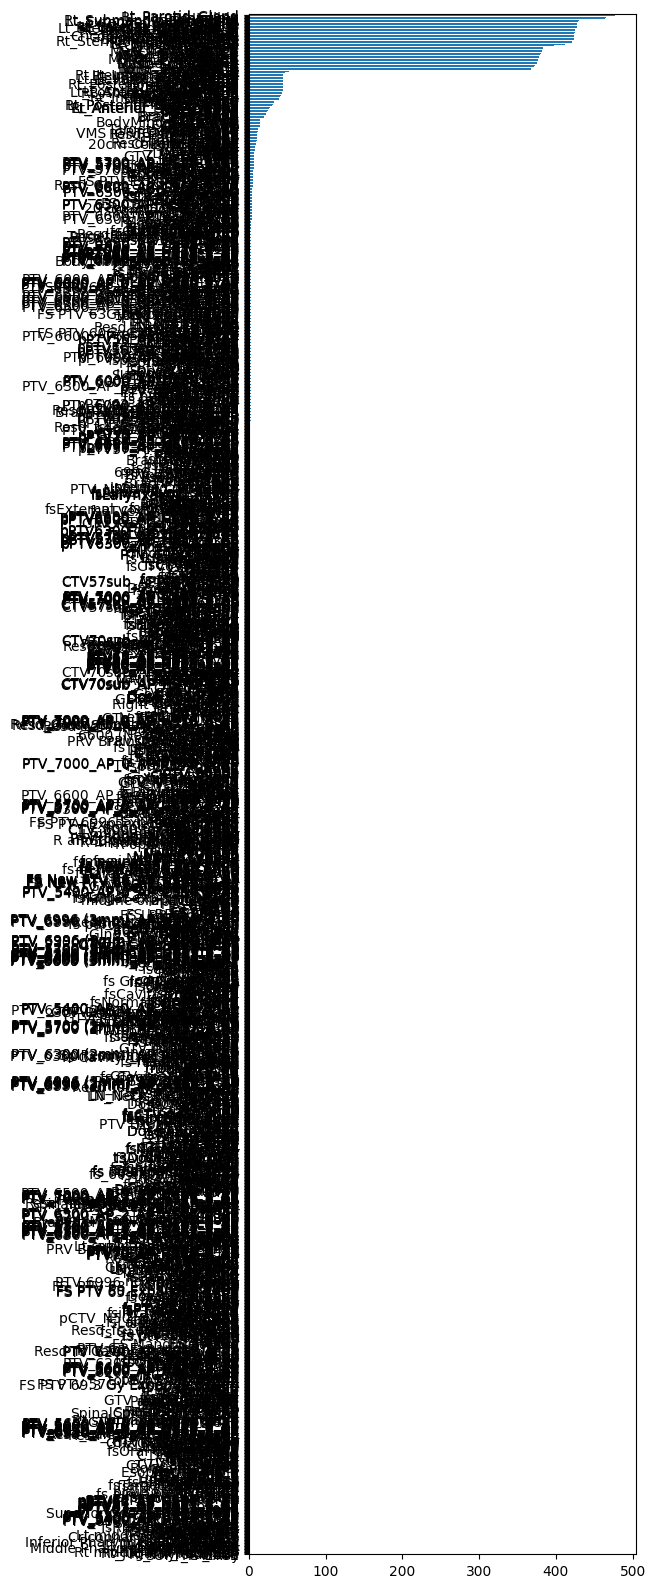

In [8]:
#The organ counts are variable. and have name inconsistencies. These will probably be different on a different dataset
organ_counts = {}
for _,row in df.iterrows():
    count = organ_counts.get(row['ROI'],0)
    organ_counts[row['ROI']] = count + 1
pd.Series(organ_counts).sort_values().plot(kind='barh',ax=plt.subplots(1,1,figsize=(5,20))[1])

In [9]:
#For reference, I use a static organ list that is the organs I select for and is also a fixed order for arrays of organ values
Const.organ_list

['Esophagus',
 'Spinal_Cord',
 'Lt_Brachial_Plexus',
 'Rt_Brachial_Plexus',
 'Cricopharyngeal_Muscle',
 'Cricoid_cartilage',
 'IPC',
 'MPC',
 'Brainstem',
 'Larynx',
 'Thyroid_cartilage',
 'Rt_Sternocleidomastoid_M',
 'Rt_Mastoid',
 'Rt_Parotid_Gland',
 'Rt_Medial_Pterygoid_M',
 'Rt_Lateral_Pterygoid_M',
 'Rt_Masseter_M',
 'Lt_Sternocleidomastoid_M',
 'Lt_Mastoid',
 'Lt_Parotid_Gland',
 'Lt_Submandibular_Gland',
 'Lt_Medial_Pterygoid_M',
 'Lt_Lateral_Pterygoid_M',
 'Lt_Masseter_M',
 'Supraglottic_Larynx',
 'SPC',
 'Rt_Submandibular_Gland',
 'Hyoid_bone',
 'Soft_Palate',
 'Genioglossus_M',
 'Tongue',
 'Rt_Ant_Digastric_M',
 'Lt_Ant_Digastric_M',
 'Mylogeniohyoid_M',
 'Extended_Oral_Cavity',
 'Mandible',
 'Hard_Palate',
 'Lower_Lip',
 'Upper_Lip',
 'Glottic_Area']

In [8]:
#In the dass code, the spellchecker was there to fix organ names and align them with the CAMPRT dataset, 
#which is what I was working on at the beginning of the project
#Furture projects will probably have a seperate thing.

In [10]:
#General Data Cleanup, may be required in future datasets
#enforce value columns to be numbers
def fix_df(df):
    df = df.drop_duplicates(subset=['id','ROI','volume'])
    df = df[df.mean_dose != 'error']
    #make sure volume and dose fields are actual numbers
    for col in df.columns:
        if 'dose' in col.lower() or 'volume' in col.lower():
            df[col] = df[col].astype(float)
    hist_cols = [c for c in df.columns if (re.match(r'[DV]\d+',c) is not None)]
    df[hist_cols] = df[hist_cols].astype('float16')
    df = df[~df.id.isna()]
    df['id'] = df.id.astype(int)
    return df
    

df = fix_df(df)
df.head()

/Users/siyuanzhao/anaconda3/envs/VDS/lib/python3.10/site-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()
/Users/siyuanzhao/anaconda3/envs/VDS/lib/python3.10/site-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,id,Structure,D10,D15,D2,D20,D25,D30,D35,D40,...,V60,V65,V70,V75,V80,volume,mean_dose,min_dose,max_dose,ROI
0,101417584648,A_Carotid_Int_L,60.12500,59.562500,60.500000,59.031250,58.812500,58.656250,58.531250,58.343750,...,0.109863,0.032959,0.032959,0.032959,0.032959,0.002351,57.087835,10.293238,60.583722,A_Carotid_Int_L
1,101417584648,A_Carotid_Int_R,63.78125,63.406250,65.125000,63.062500,62.843750,62.625000,62.281250,62.000000,...,0.685059,0.027405,0.013702,0.013702,0.013702,0.001886,60.617408,44.057339,65.649604,A_Carotid_Int_R
2,101417584648,Bone_Hyoid,68.12500,67.937500,68.375000,67.875000,67.750000,67.687500,67.562500,67.500000,...,0.985840,0.887207,0.014084,0.014084,0.014084,0.001834,66.943173,59.967373,68.585705,Hyoid_bone
3,101417584648,Bone_Manubrium,6.21875,4.539062,12.992188,4.332031,3.796875,3.644531,3.527344,3.130859,...,0.003611,0.003611,0.003611,0.003611,0.003611,0.014312,3.619052,1.774114,15.990244,Bone_Manubrium
4,101417584648,Bone_Mastoid_L,24.03125,22.437500,26.906250,21.765625,20.281250,19.687500,19.500000,18.859375,...,0.054047,0.054047,0.054047,0.054047,0.054047,0.000956,18.000852,11.520659,26.955767,Lt_Mastoid


In [11]:
def filter_valid_patients(df,organ_list, max_missing_ratio=.5,print_out=True):
    df = df.copy()
    dfs = []
    for pid,subdf in df.groupby('id'):
        
        rois = set([i for i in np.unique(subdf.ROI) if i in organ_list])
        n_rois = len(rois)
        n_missing = np.abs(n_rois - len(organ_list))
        if print_out:
            if n_missing != 0:
                print('patient ', pid, 'has', n_missing,'organs off')
        if subdf[subdf.duplicated(subset=['ROI','Structure'],keep=False)].loc[:,['ROI','Structure']].shape[0] > 0:
            print('patient',pid,'has duplicate organs?')
            print(subdf[subdf.duplicated(subset=['ROI','Structure'],keep=False)].loc[:,['ROI','Structure']])
        max_missing = len(organ_list)*max_missing_ratio
        flag = (n_missing < max_missing)
        if flag:
            dfs.append(subdf)
    valid_df = pd.concat(dfs)
    print('valid patients:',len(valid_df.id.unique()),'out of',len(df.id.unique()))
    return valid_df

##This code filters patients based on certain missing values. Here are removing people with more than half the organs in Const.organ_list
filtered_df = filter_valid_patients(df,Const.organ_list,print_out=False)

valid patients: 426 out of 485


In [12]:
#add in missing organs from organ_list for each patient
#so when we turn it into an array the values will be there
#by default, these are nan
def add_patient_organs(pid,patient_df,organ_list):
    pdf = patient_df.copy()
    rois = np.unique(patient_df.ROI.values)
    for organ in organ_list:
        if organ not in rois:
            entry = pd.Series([pid,'missing',organ],index=['id','Structure','ROI'])
            pdf = pd.concat([pd.DataFrame(entry).T,pdf],ignore_index=True)
    return pdf

def add_missing_organs(df,organ_list):
    dfs = []
    for pid,subdf in df.groupby('id'):
        subdf = add_patient_organs(pid,subdf,organ_list).set_index("ROI")
        subdf = subdf.loc[organ_list]
        subdf = subdf.reset_index()
        dfs.append(subdf)
    return pd.concat(dfs)

clean_df = add_missing_organs(filtered_df,Const.organ_list)
clean_df.head()

/Users/siyuanzhao/anaconda3/envs/VDS/lib/python3.10/site-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()
/Users/siyuanzhao/anaconda3/envs/VDS/lib/python3.10/site-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,ROI,id,Structure,D10,D15,D2,D20,D25,D30,D35,...,V5,V60,V65,V70,V75,V80,volume,mean_dose,min_dose,max_dose
0,Esophagus,101417584648,Esophagus_U,30.12500,29.6875,32.5625,28.796875,28.34375,27.859375,27.515625,...,0.868164,0.004002,0.004002,0.004002,0.004002,0.004002,0.006458,22.078509,1.887041,33.349332
1,Spinal_Cord,101417584648,SpinalCord_Cerv,33.56250,33.1250,34.8750,32.437500,31.78125,31.359375,30.703125,...,1.000000,0.001923,0.001923,0.001923,0.001923,0.001923,0.013434,26.331578,12.034635,35.409457
2,Lt_Brachial_Plexus,101417584648,Brachial_Plex_L,56.68750,55.8750,57.6250,55.187500,54.59375,53.625000,52.406250,...,1.000000,0.003571,0.003571,0.003571,0.003571,0.003571,0.007234,47.675178,23.075091,58.577422
3,Rt_Brachial_Plexus,101417584648,Brachial_Plex_R,63.03125,62.0625,64.9375,61.031250,60.18750,59.156250,58.281250,...,1.000000,0.260254,0.017853,0.002550,0.002550,0.002550,0.010127,50.281901,8.637328,66.874914
4,Cricopharyngeal_Muscle,101417584648,Cricopharyngeus,36.59375,35.7500,43.7500,33.781250,33.21875,31.437500,30.421875,...,1.000000,0.014084,0.014084,0.014084,0.014084,0.014084,0.001834,30.144448,21.592265,44.083724


In [13]:
# Fix the two problematic patients so each has exactly 40 organs (ROIs)
# Rebuild clean_df to avoid any accidental in-kernel mutations from prior experiments
clean_df = add_missing_organs(filtered_df, Const.organ_list)

def _fix_patient_duplicate_rois(df, pid, preferred_structure_by_roi):
    pdf = df[df['id'] == pid].copy()
    fixed_rows = []
    for roi in Const.organ_list:
        g = pdf[pdf['ROI'] == roi]
        if g.empty:
            # should not happen after add_missing_organs, but keep it robust
            base = {c: np.nan for c in df.columns}
            base['id'] = pid
            base['Structure'] = 'missing'
            base['ROI'] = roi
            fixed_rows.append(pd.Series(base))
            continue
        if g.shape[0] == 1:
            fixed_rows.append(g.iloc[0])
            continue
        preferred_structure = preferred_structure_by_roi.get(roi)
        if preferred_structure is not None:
            preferred = g[g['Structure'] == preferred_structure]
            if not preferred.empty:
                fixed_rows.append(preferred.iloc[0])
                continue
        # fallback: prefer a non-missing row if present, else first row
        non_missing = g[g['Structure'] != 'missing']
        fixed_rows.append((non_missing.iloc[0] if not non_missing.empty else g.iloc[0]))

    fixed_pdf = pd.DataFrame(fixed_rows)
    fixed_pdf = fixed_pdf.drop_duplicates(subset=['ROI'], keep='first')
    fixed_pdf = fixed_pdf.set_index('ROI').loc[Const.organ_list].reset_index()
    fixed_pdf['id'] = pid
    return fixed_pdf

p167 = _fix_patient_duplicate_rois(
    clean_df,
    167030187881,
    preferred_structure_by_roi={
        'Cricopharyngeal_Muscle': 'Cricopharyngeal_Muscle',
    },
)
p312 = _fix_patient_duplicate_rois(
    clean_df,
    312597899074,
    preferred_structure_by_roi={
        'Lt_Parotid_Gland': 'Lt_Parotid_Gland',
        'Lt_Submandibular_Gland': 'Lt_Submandibular_Gland',
        'Rt_Parotid_Gland': 'Rt_Parotid_Gland',
    },
)

clean_df = pd.concat([
    clean_df[~clean_df['id'].isin([167030187881, 312597899074])],
    p167,
    p312,
], ignore_index=True)

# sanity checks
for pid in [167030187881, 312597899074]:
    pdf = clean_df[clean_df['id'] == pid]
    print('patient', pid, 'roi_rows:', pdf.shape[0], 'unique_rois:', pdf['ROI'].nunique(), 'dup_roi_rows:', int(pdf.duplicated(subset=['ROI']).sum()))
    assert pdf.shape[0] == len(Const.organ_list)
    assert pdf['ROI'].nunique() == len(Const.organ_list)
    assert int(pdf.duplicated(subset=['ROI']).sum()) == 0

patient 167030187881 roi_rows: 40 unique_rois: 40 dup_roi_rows: 0
patient 312597899074 roi_rows: 40 unique_rois: 40 dup_roi_rows: 0


In [14]:
def get_value_array(df,cols,organ_list,input_median=True, rows='patients',as_df=True):
    #returns a value array, with rows=patients, it will roll up the organs for a paeitn
    #keep_d2 set to false will return a 3d matrix where the second dimension is the organs in same order as organ list
    #as_df needs to be 2d, will include headers and ID
    #cols is the value arrays to inclue from
    if 'Structure' in cols or 'ROI' in cols:
        cols = list(set(cols) - set(['Structure','ROI']))
    cols = [c for c in cols if c not in ['Structure','ROI','id']]
    try:
        subdf = df[cols].astype(float)
        subdf['id'] = df.id
        subdf['ROI'] = df['ROI']
        subdf = subdf[subdf.ROI.isin(organ_list)]
    except Exception as e:
        print('error getting values as floats')
        print(e)
    if input_median:
        for col in cols:
            nanvals = np.isnan(subdf[col])
            subdf.loc[nanvals,col] = subdf[~nanvals][col].median()
    if rows== 'organs':
        if as_df:
            return subdf
        else:
            return subdf.drop(['id','ROI'],axis=1).values
    else:
        assert(rows=='patients')
        values = []
        pids = sorted(subdf.id.unique())
        colnames =[]
        for roi in subdf.ROI.unique():
            for c in subdf.columns:
                if c != 'id' and c != 'ROI':
                    colnames.append(roi + '_' + c)
        for pid in pids:
            pdf = subdf[subdf.id == pid]
#             for pid, pdf in subdf.groupby('id'):
#                 pids.append(pid)
            pdf = pdf[pdf.ROI.apply(lambda x: x in organ_list)]
            rows = pdf.drop(['id','ROI'],axis=1)
            values.append(rows.values.ravel())
        if as_df:
            returndf = pd.DataFrame(np.array(values),index=pids,columns=colnames)
            returndf.index.name = 'id'
            return returndf
        else:
            values = np.array(values)
            return values

#this will roll up the dvh dataframe to be per-patient instead of per ROI
#second argument is the list of columns to input
#third argument is list of organs
get_value_array(clean_df,list(clean_df.columns),Const.organ_list).head()

,Esophagus_D35,Esophagus_D25,Esophagus_D50,Esophagus_V15,Esophagus_V30,Esophagus_V55,Esophagus_V45,Esophagus_D30,Esophagus_D40,Esophagus_min_dose,...,Glottic_Area_D70,Glottic_Area_V10,Glottic_Area_V50,Glottic_Area_D5,Glottic_Area_D95,Glottic_Area_D98,Glottic_Area_D20,Glottic_Area_D2,Glottic_Area_D99,Glottic_Area_D60
id,,,,,,,,,,,,,,,,,,,,,
101417584648,27.515625,28.343750,25.937500,0.788086,0.116028,0.004002,0.004002,27.859375,26.750000,1.887041,...,25.765625,1.000000,0.029419,40.718750,22.875000,22.171875,37.312500,43.000000,22.140625,27.656250
101923688164,26.390625,27.656250,23.093750,0.587402,0.002184,0.002184,0.002184,27.218750,25.234375,0.820000,...,6.421875,0.463867,0.014496,22.531250,4.671875,4.539062,15.718750,22.859375,4.468750,9.554688
102209659698,0.161499,0.211792,0.095581,0.066650,0.066650,0.066650,0.066650,0.187012,0.135986,0.000000,...,0.896973,0.016953,0.016953,5.406250,0.659180,0.623535,2.310547,6.582031,0.611816,0.956055
102700862898,11.796875,14.453125,5.398438,0.202148,0.002174,0.002174,0.002174,13.367188,10.351562,0.785259,...,10.109375,0.765625,0.007812,18.765625,9.140625,8.757812,14.859375,22.546875,8.125000,10.640625
102934140275,8.476562,9.453125,4.875000,0.003584,0.003584,0.003584,0.003584,8.906250,8.140625,0.631753,...,8.742188,0.306396,0.008064,11.625000,7.972656,7.574219,10.507812,11.953125,7.511719,9.062500


In [15]:
#we can also use a subset of the organs and dose values
def get_dvh_columns(df,key,steps=None):
        good_cols = []
        dvh=df.copy()
        for c in dvh.columns:
            match = re.match(key+r'(\d+)', c)
            if match is not None:
                use = True
                if steps is not None and match.group(1) is not None:
                    value = int(match.group(1))
                    if value not in steps:
                        use = False
                if use:
                    good_cols.append(match.group(0))
        keys = sorted(good_cols, key = get_dvhcol_pos)
        pos = [get_dvhcol_pos(x) for x in good_cols]
        return keys, pos
    
def get_dvhcol_pos(x):
    m = re.match('[DV]'+r'(\d+)',x)
    if m is not None:
        return int(m.group(1))
    else:
        return -1
#this extracts the sorted values for dose volume histograms from the dataframe columns
#key is either 'V' (for volume) or 'D' (for dose). DASS uses 'D'
get_dvh_columns(clean_df,'D')

(['D2',
  'D5',
  'D10',
  'D15',
  'D20',
  'D25',
  'D30',
  'D35',
  'D40',
  'D45',
  'D50',
  'D55',
  'D60',
  'D65',
  'D70',
  'D75',
  'D80',
  'D85',
  'D90',
  'D95',
  'D97',
  'D98',
  'D99'],
 [10,
  15,
  2,
  20,
  25,
  30,
  35,
  40,
  45,
  5,
  50,
  55,
  60,
  65,
  70,
  75,
  80,
  85,
  90,
  95,
  97,
  98,
  99])

In [17]:
#We can thus get a subset of the organ dose values
get_value_array(clean_df,get_dvh_columns(clean_df,'D')[0],['Extended_Oral_Cavity','Esophagus']).head()

,Esophagus_D2,Esophagus_D5,Esophagus_D10,Esophagus_D15,Esophagus_D20,Esophagus_D25,Esophagus_D30,Esophagus_D35,Esophagus_D40,Esophagus_D45,...,Extended_Oral_Cavity_D65,Extended_Oral_Cavity_D70,Extended_Oral_Cavity_D75,Extended_Oral_Cavity_D80,Extended_Oral_Cavity_D85,Extended_Oral_Cavity_D90,Extended_Oral_Cavity_D95,Extended_Oral_Cavity_D97,Extended_Oral_Cavity_D98,Extended_Oral_Cavity_D99
id,,,,,,,,,,,,,,,,,,,,,
101417584648,32.562500,30.843750,30.125000,29.687500,28.796875,28.343750,27.859375,27.515625,26.750000,26.328125,...,30.171875,28.296875,25.890625,23.750000,21.500000,18.562500,14.992188,13.320312,12.117188,9.054688
101923688164,28.640625,28.515625,28.343750,28.156250,27.968750,27.656250,27.218750,26.390625,25.234375,24.515625,...,66.562500,63.718750,60.062500,54.750000,47.750000,40.312500,33.437500,30.140625,28.171875,26.265625
102209659698,0.300049,0.300049,0.283936,0.260010,0.235840,0.211792,0.187012,0.161499,0.135986,0.110474,...,10.585938,9.976562,9.367188,8.726562,8.031250,7.121094,6.054688,5.632812,5.453125,5.144531
102700862898,19.281250,17.296875,16.218750,15.648438,15.015625,14.453125,13.367188,11.796875,10.351562,8.851562,...,16.062500,14.859375,13.734375,12.554688,11.437500,10.453125,9.257812,8.523438,7.976562,7.343750
102934140275,12.523438,11.679688,11.101562,10.406250,9.812500,9.453125,8.906250,8.476562,8.140625,7.710938,...,15.007812,14.234375,13.359375,12.445312,11.390625,10.218750,8.992188,8.328125,8.093750,7.812500


In [18]:
#now we roll up the values so each column is an array (so we can compute on them more easily)
#order is order of Const.organ_list
dvh_df = get_value_array(clean_df,clean_df.columns,Const.organ_list)
cols = [c for c in clean_df.columns if c not in ['ROI','Structure','id']]
vallist = []
for col in cols:
    colnames = [o + '_' + col for o in Const.organ_list]
    valdf = dvh_df[colnames].sort_index()
    vals = valdf.values.tolist()
    vallist.append(vals)
valdf = pd.DataFrame(np.swapaxes(np.array(vallist),0,1).tolist(),index=dvh_df.index,columns=cols)
valdf.head()

,D10,D15,D2,D20,D25,D30,D35,D40,D45,D5,...,V5,V60,V65,V70,V75,V80,volume,mean_dose,min_dose,max_dose
id,,,,,,,,,,,,,,,,,,,,,
101417584648,"[30.125, 33.5625, 56.6875, 63.03125, 36.59375,...","[29.6875, 33.125, 55.875, 62.0625, 35.75, 43.0...","[32.5625, 34.875, 57.625, 64.9375, 43.75, 56.4...","[28.796875, 32.4375, 55.1875, 61.03125, 33.781...","[28.34375, 31.78125, 54.59375, 60.1875, 33.218...","[27.859375, 31.359375, 53.625, 59.15625, 31.43...","[27.515625, 30.703125, 52.40625, 58.28125, 30....","[26.75, 29.921875, 51.25, 57.40625, 29.453125,...","[26.328125, 29.171875, 50.4375, 56.625, 29.0, ...","[30.84375, 34.28125, 57.21875, 63.65625, 42.03...",...,"[0.8681640625, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1...","[0.004001617431640625, 0.001922607421875, 0.00...","[0.004001617431640625, 0.001922607421875, 0.00...","[0.004001617431640625, 0.001922607421875, 0.00...","[0.004001617431640625, 0.001922607421875, 0.00...","[0.004001617431640625, 0.001922607421875, 0.00...","[0.006458488, 0.013433655181322, 0.007233507, ...","[22.078509351808, 26.3315778, 47.6751775849142...","[1.887040896, 12.034634976, 23.07509069, 8.637...","[33.34933181, 35.40945699, 58.577422176000006,..."
101923688164,"[28.34375, 27.75, 51.75, 46.9375, 19.328125, 2...","[28.15625, 26.5, 47.625, 43.3125, 15.546875, 2...","[28.640625, 34.15625, 56.96875, 56.1875, 31.92...","[27.96875, 25.625, 43.4375, 38.25, 14.6796875,...","[27.65625, 25.046875, 39.34375, 36.5625, 10.17...","[27.21875, 24.578125, 36.5, 36.0625, 8.9453125...","[26.390625, 24.21875, 35.71875, 35.75, 7.70312...","[25.234375, 23.953125, 35.15625, 35.4375, 7.30...","[24.515625, 23.71875, 34.8125, 35.09375, 6.679...","[28.515625, 30.203125, 54.875, 53.4375, 26.109...",...,"[0.6748046875, 0.939453125, 0.9970703125, 0.87...","[0.0021839141845703125, 0.0011644363403320312,...","[0.0021839141845703125, 0.0011644363403320312,...","[0.0021839141845703125, 0.0011644363403320312,...","[0.0021839141845703125, 0.0011644363403320312,...","[0.0021839141845703125, 0.0011644363403320312,...","[0.027185785, 0.050988185, 0.020419017, 0.0304...","[16.862794759825327, 20.824237485448197, 36.83...","[0.8200000000000001, 4.64, 4.94, 1.31, 4.43, 4...","[28.83, 39.02, 58.68, 58.33, 33.41000000000000..."
102209659698,"[0.283935546875, 10.390625, 5.171875, 2.599609...","[0.260009765625, 10.09375, 1.8515625, 1.637695...","[0.300048828125, 11.1640625, 13.3515625, 4.761...","[0.23583984375, 9.875, 1.263671875, 1.25, 0.63...","[0.2117919921875, 9.6640625, 0.96435546875, 0....","[0.18701171875, 9.4765625, 0.81591796875, 0.75...","[0.1614990234375, 9.296875, 0.6923828125, 0.60...","[0.135986328125, 9.078125, 0.6240234375, 0.507...","[0.1104736328125, 8.9140625, 0.55078125, 0.437...","[0.300048828125, 10.7734375, 10.9375, 3.283203...",...,"[0.066650390625, 0.578125, 0.1025390625, 0.011...","[0.066650390625, 0.002109527587890625, 0.00366...","[0.066650390625, 0.002109527587890625, 0.00366...","[0.066650390625, 0.002109527587890625, 0.00366...","[0.066650390625, 0.002109527587890625, 0.00366...","[0.066650390625, 0.002109527587890625, 0.00366...","[0.008040867, 0.013188134, 0.007595697, 0.0075...","[0.1006339662622837, 5.756943881875527, 1.6494...","[0.0, 0.043546908, 0.117324727, 0.113006025, 0...","[0.373207797, 11.63458211, 15.70855729, 6.6860..."
102700862898,"[16.21875, 15.4765625, 25.71875, 34.5625, 22.2...","[15.6484375, 14.78125, 25.34375, 33.875, 21.32...","[19.28125, 17.421875, 26.6875, 36.9375, 23.484...","[15.015625, 14.1796875, 25.0, 33.4375, 20.8437...","[14.453125, 13.6796875, 24.453125, 33.0625, 20...","[13.3671875, 13.375, 23.953125, 32.5, 19.875, ...","[11.796875, 13.140625, 22.984375, 31.953125, 1...","[10.3515625, 12.890625, 22.375, 31.40625, 19.1...","[8.8515625, 12.5546875, 21.53125, 30.78125, 18...","[17.296875, 16.375, 26.34375, 34.96875, 22.875...",...,"[0.50634765625, 1.0, 1.0, 0.98388671875, 1.0, ...","[0.00217437744140625, 0.0016450881958007812, 0...","[0.00217437744140625, 0.0016450881958007812, 0...","[0.0021743

In [19]:
# Map valdf index: Anonymized_ID -> STIEFEL_ID using provided spreadsheets
# Assumes you have already run the cell that loads `map1` and `map2`.

map_df = pd.concat(
    [map1[['Anonymized_ID', 'STIEFEL_ID']], map2[['Anonymized_ID', 'STIEFEL_ID']]],
    ignore_index=True,
).dropna()

map_df['Anonymized_ID'] = map_df['Anonymized_ID'].astype(int)
map_df['STIEFEL_ID'] = map_df['STIEFEL_ID'].astype(str).str.strip()

# Check for conflicting mappings (same Anonymized_ID -> multiple STIEFEL_IDs)
conflicts = (
    map_df.groupby('Anonymized_ID')['STIEFEL_ID']
    .nunique()
    .reset_index(name='n_unique')
)
conflict_ids = conflicts.loc[conflicts['n_unique'] > 1, 'Anonymized_ID'].tolist()
if len(conflict_ids) > 0:
    raise ValueError(f'Conflicting STIEFEL_ID mappings for {len(conflict_ids)} Anonymized_IDs. Example: {conflict_ids[:10]}')

# Build mapping dict
map_dict = dict(zip(map_df['Anonymized_ID'].values, map_df['STIEFEL_ID'].values))

# Apply mapping
valdf = valdf.reset_index().rename(columns={'id': 'Anonymized_ID'})
valdf['id'] = valdf['Anonymized_ID'].map(map_dict)

missing = valdf['id'].isna()
if missing.any():
    missing_ids = valdf.loc[missing, 'Anonymized_ID'].astype(int).unique().tolist()
    raise ValueError(f'Missing STIEFEL_ID mapping for {len(missing_ids)} ids. Example: {missing_ids[:10]}')

valdf = valdf.set_index('id')
valdf.index.name = 'id'

valdf.head()

,Anonymized_ID,D10,D15,D2,D20,D25,D30,D35,D40,D45,...,V5,V60,V65,V70,V75,V80,volume,mean_dose,min_dose,max_dose
id,,,,,,,,,,,,,,,,,,,,,
STIEFEL_364,101417584648,"[30.125, 33.5625, 56.6875, 63.03125, 36.59375,...","[29.6875, 33.125, 55.875, 62.0625, 35.75, 43.0...","[32.5625, 34.875, 57.625, 64.9375, 43.75, 56.4...","[28.796875, 32.4375, 55.1875, 61.03125, 33.781...","[28.34375, 31.78125, 54.59375, 60.1875, 33.218...","[27.859375, 31.359375, 53.625, 59.15625, 31.43...","[27.515625, 30.703125, 52.40625, 58.28125, 30....","[26.75, 29.921875, 51.25, 57.40625, 29.453125,...","[26.328125, 29.171875, 50.4375, 56.625, 29.0, ...",...,"[0.8681640625, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1...","[0.004001617431640625, 0.001922607421875, 0.00...","[0.004001617431640625, 0.001922607421875, 0.00...","[0.004001617431640625, 0.001922607421875, 0.00...","[0.004001617431640625, 0.001922607421875, 0.00...","[0.004001617431640625, 0.001922607421875, 0.00...","[0.006458488, 0.013433655181322, 0.007233507, ...","[22.078509351808, 26.3315778, 47.6751775849142...","[1.887040896, 12.034634976, 23.07509069, 8.637...","[33.34933181, 35.40945699, 58.577422176000006,..."
STIEFEL_301,101923688164,"[28.34375, 27.75, 51.75, 46.9375, 19.328125, 2...","[28.15625, 26.5, 47.625, 43.3125, 15.546875, 2...","[28.640625, 34.15625, 56.96875, 56.1875, 31.92...","[27.96875, 25.625, 43.4375, 38.25, 14.6796875,...","[27.65625, 25.046875, 39.34375, 36.5625, 10.17...","[27.21875, 24.578125, 36.5, 36.0625, 8.9453125...","[26.390625, 24.21875, 35.71875, 35.75, 7.70312...","[25.234375, 23.953125, 35.15625, 35.4375, 7.30...","[24.515625, 23.71875, 34.8125, 35.09375, 6.679...",...,"[0.6748046875, 0.939453125, 0.9970703125, 0.87...","[0.0021839141845703125, 0.0011644363403320312,...","[0.0021839141845703125, 0.0011644363403320312,...","[0.0021839141845703125, 0.0011644363403320312,...","[0.0021839141845703125, 0.0011644363403320312,...","[0.0021839141845703125, 0.0011644363403320312,...","[0.027185785, 0.050988185, 0.020419017, 0.0304...","[16.862794759825327, 20.824237485448197, 36.83...","[0.8200000000000001, 4.64, 4.94, 1.31, 4.43, 4...","[28.83, 39.02, 58.68, 58.33, 33.41000000000000..."
STIEFEL_1042,102209659698,"[0.283935546875, 10.390625, 5.171875, 2.599609...","[0.260009765625, 10.09375, 1.8515625, 1.637695...","[0.300048828125, 11.1640625, 13.3515625, 4.761...","[0.23583984375, 9.875, 1.263671875, 1.25, 0.63...","[0.2117919921875, 9.6640625, 0.96435546875, 0....","[0.18701171875, 9.4765625, 0.81591796875, 0.75...","[0.1614990234375, 9.296875, 0.6923828125, 0.60...","[0.135986328125, 9.078125, 0.6240234375, 0.507...","[0.1104736328125, 8.9140625, 0.55078125, 0.437...",...,"[0.066650390625, 0.578125, 0.1025390625, 0.011...","[0.066650390625, 0.002109527587890625, 0.00366...","[0.066650390625, 0.002109527587890625, 0.00366...","[0.066650390625, 0.002109527587890625, 0.00366...","[0.066650390625, 0.002109527587890625, 0.00366...","[0.066650390625, 0.002109527587890625, 0.00366...","[0.008040867, 0.013188134, 0.007595697, 0.0075...","[0.1006339662622837, 5.756943881875527, 1.6494...","[0.0, 0.043546908, 0.117324727, 0.113006025, 0...","[0.373207797, 11.63458211, 15.70855729, 6.6860..."
STIEFEL_973,102700862898,"[16.21875, 15.4765625, 25.71875, 34.5625, 22.2...","[15.6484375, 14.78125, 25.34375, 33.875, 21.32...","[19.28125, 17.421875, 26.6875, 36.9375, 23.484...","[15.015625, 14.1796875, 25.0, 33.4375, 20.8437...","[14.453125, 13.6796875, 24.453125, 33.0625, 20...","[13.3671875, 13.375, 23.953125, 32.5, 19.875, ...","[11.796875, 13.140625, 22.984375, 31.953125, 1...","[10.3515625, 12.890625, 22.375, 31.40625, 19.1...","[8.8515625, 12.5546875, 21.53125, 30.78125, 18...",...,"[0.50634765625, 1.0, 1.0, 0.98388671875, 1.0, ...","[0.00217437744140625, 0.0016450881958007812, 0...","[0.00217437744140625, 0.0016450881958007812, 0...","[0.00217437744140625, 0.0016450881958007812, 0...","[0.00217437744140625, 0.0016450881958007812, 0...","[0.00217437744140625, 0.0016450881958007812, 0...","[0

In [37]:
#we then want to merge the data with the mdasi data
# df = load_mdasi()
mdasi_df = Symptom.load_mdasi()
mdasi_df

before drop count 823
after drop count 535


,performance_score,subsite,age,baseline_mbs_digest,id,t_stage,n_stage,rt,ic,chemotherapy,...,symptoms_work,symptoms_relations,symptoms_walking,symptoms_enjoy,t4,n3,BOT,Tonsil,old,digest_increase
0,0,BOT,72.0,NaN,1,t1,n2b,1.0,0.0,concurrent_chemotherapy,...,"[0.0, nan, nan, nan, nan, 0.0, 0.0, 10.0, 4.0,...","[0.0, nan, nan, nan, nan, 0.0, 0.0, 0.0, 0.0, ...","[0.0, nan, nan, nan, nan, 0.0, 3.0, 7.0, 4.0, ...","[0.0, nan, nan, nan, nan, 0.0, 3.0, 1.0, 0.0, ...",0,0,1,0,1,0
6,1,NOS,48.0,NaN,7,t0,n2b,1.0,0.0,concurrent_chemotherapy,...,"[0.0, 0.0, 0.0, 1.0, 2.0, nan, 2.0, nan, 2.0, ...","[0.0, 2.0, 2.0, 1.0, 2.0, nan, 2.0, nan, 0.0, ...","[0.0, 0.0, 0.0, 2.0, 1.0, nan, 1.0, nan, 1.0, ...","[0.0, 0.0, 1.0, 2.0, 1.0, nan, 1.0, nan, 1.0, ...",0,0,0,0,0,0
7,0,BOT,61.0,NaN,8,t2,n2c,1.0,0.0,concurrent_chemotherapy,...,"[1.0, 1.0, nan, nan, nan, nan, nan, nan, 3.0, ...","[0.0, 1.0, nan, nan, nan, nan, nan, nan, 0.0, ...","[0.0, 0.0, nan, nan, nan, nan, nan, nan, 0.0, ...","[1.0, 1.0, nan, nan, nan, nan, nan, nan, 3.0, ...",0,1,1,0,1,0
8,0,Tonsil,50.0,NaN,9,t1,n2a,1.0,0.0,concurrent_chemotherapy,...,"[0.0, 0.0, nan, nan, 3.0, 3.0, 3.0, 2.0, 1.0, ...","[0.0, 0.0, nan, nan, 1.0, 0.0, 1.0, 1.0, 1.0, ...","[0.0, 0.0, nan, nan, 0.0, 0.0, 1.0, 2.0, 1.0, ...","[0.0, 1.0, nan, nan, 3.0, 2.0, 2.0, 3.0, 1.0, ...",0,0,0,1,0,0
9,1,BOT,70.0,NaN,10,t4,n2b,1.0,1.0,induction+concurrent,...,"[0.0, 0.0, 1.0, 2.0, 1.0, 2.0, 4.0, 4.0, 0.0, ...","[0.0, 0.0, 2.0, 2.0, 1.0, 2.0, 3.0, 4.0, 1.0, ...","[0.0, 0.0, 0.0, 2.0, 1.0, 0.0, 3.0, 2.0, 0.0, ...","[0.0, 1.0, 1.0, 2.0, 1.0, 3.0, 6.0, 3.0, 1.0, ...",1,0,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
810,0,Tonsil,54.0,NaN,811,t2,n1,1.0,0.0,concurrent_chemotherapy,...,"[0.0, nan, 0.0, nan, nan, 0.0, nan, 1.0, nan, ...","[0.0, nan, 0.0, nan, nan, 0.0, nan, 1.0, nan, ...","[0.0, nan, 0.0, nan, nan, 0.0, nan, 0.0, nan, ...","[0.0, nan, 0.0, nan, nan, 0.0, nan, 2.0, nan, ...",0,0,0,1,0,0
812,0,NOS,68.0,NaN,813,NaN,NaN,1.0,0.0,concurrent_chemotherapy,...,"[0.0, nan, 0.0, 0.0, 0.0, 0.0, 0.0, 2.0, nan, ...","[0.0, nan, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, nan, ...","[0.0, nan, 0.0, 0.0, 0.0, 2.0, 1.0, 1.0, nan, ...","[1.0, nan, 1.0, 1.0, 0.0, 2.0, 2.0, 3.0, nan, ...",0,0,0,0,1,0
815,NaN,BOT,78.0,NaN,816,tx,n1,1.0,1.0,NaN,...,"[0.0, 0.0, nan, 1.0, 1.0, 2.0, 0.0, 1.0, nan, ...","[0.0, 0.0, nan, 0.0, 1.0, 2.0, 0.0, 1.0, nan, ...","[0.0, 0.0, nan, 0.0, 0.0, 1.0, 0.0, 1.0, nan, ...","[0.0, 0.0, nan, 1.0, 1.0, 1.0, 1.0, 1.0, nan, ...",0,0,1,0,1,0
818,0,BOT,52.0,NaN,819,t1,n1,1.0,0.0,concurrent_chemotherapy,...,"[0.0, 0.0, 0.0, nan, nan, 5.0, nan, nan, nan, ...","[0.0, 0.0, 0.0, nan, nan, 4.0, nan, nan, nan, ...","[0.0, 0.0, 0.0, nan, nan, 0.0, nan, nan, nan, ...","[0.0, 0.0, 0.0, nan, nan, 4.0, nan, nan, nan, ...",0,0,1,0,0,0


In [38]:
#The most important features here are the symptom arrays "symptoms_<symptom_name"
#There is a value for dates that is the weeks since start of treatment that corresponds to the dates of each symptom
mdasi_df.iloc[0][['symptoms_drymouth','dates']].values.tolist()

[[0.0, nan, nan, nan, nan, 1.0, 1.0, nan, 0.0, 0.0, nan, nan, nan],
 [0, 1, 2, 3, 4, 5, 6, 7, 13, 33, 59, 85, 268]]

In [39]:
#We can also train an autoencoder to predict the missing (nan) values and fill them in
#use_trained will use a saved model if it exists
#for new data, you can probably ask Guadalupe's group for their results for predicting missing symptom values
mdasi_df_imputed = Symptom.impute_symptom_df(mdasi_df,
                                             use_trained=True
                                            )
mdasi_df_imputed.iloc[0][['symptoms_drymouth','symptoms_drymouth_original','dates']].values.tolist()

[[ 0.  0.  1. ... nan nan nan]
 [ 0.  0.  1. ...  0. nan nan]
 [ 0.  0.  1. ...  2.  0. nan]
 ...
 [ 1.  0.  1. ... nan nan nan]
 [ 0.  0.  1. ... nan nan nan]
 [ 1.  0.  1. ... nan nan nan]]
error (%) 0.5969729614411226


[[0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 2.0, 0.0, 0.0, 2.0, 3.0, 0.0],
 [0.0, nan, nan, nan, nan, 1.0, 1.0, nan, 0.0, 0.0, nan, nan, nan],
 [0, 1, 2, 3, 4, 5, 6, 7, 13, 33, 59, 85, 268]]

In [30]:
# Map MDASI ids (Anonymized_ID -> Stiefel_ID)
# Uses: Cohort_SMART2_530pts_(486pts) - STIEFEL_ID_Anonymized_20260421.xlsx
# Note: this mapping file may not cover every MDASI patient; unmapped rows are dropped.

stiefel_map_path = '../Cohort_SMART2_530pts_(486pts) - STIEFEL_ID_Anonymized_20260421.xlsx'
stiefel_map_raw = pd.read_excel(stiefel_map_path, usecols=['id', 'Stiefel_ID'])

stiefel_map = stiefel_map_raw.dropna().copy()
stiefel_map['id'] = pd.to_numeric(stiefel_map['id'], errors='coerce').astype('Int64')
stiefel_map['Stiefel_ID'] = stiefel_map['Stiefel_ID'].astype(str).str.strip()
stiefel_map = stiefel_map.dropna(subset=['id', 'Stiefel_ID'])

# ensure 1:1 mapping
conflict = stiefel_map.groupby('id')['Stiefel_ID'].nunique()
conflict_ids = conflict[conflict > 1].index.tolist()
if len(conflict_ids) > 0:
    raise ValueError(f'Conflicting Stiefel_ID for {len(conflict_ids)} ids. Example: {conflict_ids[:10]}')

stiefel_map = stiefel_map.drop_duplicates(subset=['id'], keep='first')
stiefel_dict = dict(zip(stiefel_map['id'].astype(int).values, stiefel_map['Stiefel_ID'].values))


def _apply_stiefel_id_mapping(df: pd.DataFrame, id_col: str = 'id', drop_unmapped: bool = True) -> pd.DataFrame:
    df = df.copy()

    if 'Anonymized_ID' not in df.columns:
        df['Anonymized_ID'] = pd.to_numeric(df[id_col], errors='coerce').astype('Int64')

    df[id_col] = df['Anonymized_ID'].astype('Int64').map(
        lambda x: stiefel_dict.get(int(x)) if pd.notna(x) else None
    )

    missing_mask = df[id_col].isna() & df['Anonymized_ID'].notna()
    n_missing = int(missing_mask.sum())
    if n_missing > 0:
        missing_ids = df.loc[missing_mask, 'Anonymized_ID'].astype(int).unique().tolist()
        print(f'Warning: missing Stiefel_ID mapping for {len(missing_ids)} Anonymized_IDs. Example: {missing_ids[:10]}')
        if drop_unmapped:
            df = df.loc[~missing_mask].copy()

    return df


mdasi_df = _apply_stiefel_id_mapping(mdasi_df, id_col='id', drop_unmapped=True)
mdasi_df_imputed = _apply_stiefel_id_mapping(mdasi_df_imputed, id_col='id', drop_unmapped=True)

print('Mapped mdasi_df ids to Stiefel_ID (after dropping unmapped).')
print('mdasi_df shape:', mdasi_df.shape, 'mdasi_df_imputed shape:', mdasi_df_imputed.shape)
print('Example Stiefel IDs:', mdasi_df['id'].dropna().unique()[:5])

Mapped mdasi_df ids to Stiefel_ID (after dropping unmapped).
mdasi_df shape: (349, 53) mdasi_df_imputed shape: (349, 81)
Example Stiefel IDs: ['STIEFEL_24' 'STIEFEL_26' 'STIEFEL_28' 'STIEFEL_34' 'STIEFEL_36']


In [31]:
mdasi_df.id

6        STIEFEL_24
7        STIEFEL_26
8        STIEFEL_28
9        STIEFEL_34
10       STIEFEL_36
           ...     
806    STIEFEL_1115
808    STIEFEL_1118
810    STIEFEL_1120
812    STIEFEL_1126
815    STIEFEL_1130
Name: id, Length: 349, dtype: object

In [32]:
valdf.index

Index(['STIEFEL_364', 'STIEFEL_301', 'STIEFEL_1042', 'STIEFEL_973',
       'STIEFEL_567', 'STIEFEL_91', 'STIEFEL_54', 'STIEFEL_611', 'STIEFEL_372',
       'STIEFEL_749',
       ...
       'STIEFEL_156', 'STIEFEL_1024', 'STIEFEL_132', 'STIEFEL_1057',
       'STIEFEL_762', 'STIEFEL_661', 'STIEFEL_688', 'STIEFEL_117',
       'STIEFEL_183', 'STIEFEL_101'],
      dtype='object', name='id', length=426)

In [33]:
# id is now a STIEFEL_* string (do not cast to int)
mdasi_df_imputed['id'] = mdasi_df_imputed['id'].astype(str)

In [34]:
# Merge on STIEFEL id (valdf index is STIEFEL_ID; mdasi_df_imputed has `id` column)
# Add suffixes because both sides contain `Anonymized_ID`
merged_df = valdf.join(
    mdasi_df_imputed.set_index('id'),
    how='inner',
    lsuffix='_dose',
    rsuffix='_mdasi',
)
merged_df

,Anonymized_ID_dose,D10,D15,D2,D20,D25,D30,D35,D40,D45,...,symptoms_sleep,symptoms_sob,symptoms_swallow,symptoms_taste,symptoms_teeth,symptoms_voice,symptoms_vomit,symptoms_walking,symptoms_work,Anonymized_ID_mdasi
id,,,,,,,,,,,,,,,,,,,,,
STIEFEL_301,101923688164,"[28.34375, 27.75, 51.75, 46.9375, 19.328125, 2...","[28.15625, 26.5, 47.625, 43.3125, 15.546875, 2...","[28.640625, 34.15625, 56.96875, 56.1875, 31.92...","[27.96875, 25.625, 43.4375, 38.25, 14.6796875,...","[27.65625, 25.046875, 39.34375, 36.5625, 10.17...","[27.21875, 24.578125, 36.5, 36.0625, 8.9453125...","[26.390625, 24.21875, 35.71875, 35.75, 7.70312...","[25.234375, 23.953125, 35.15625, 35.4375, 7.30...","[24.515625, 23.71875, 34.8125, 35.09375, 6.679...",...,"[3.0, 0.0, 3.0, 6.0, 3.0, 3.0, 1.0, 3.0, 5.0, ...","[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[10.0, 0.0, 0.0, 2.0, 2.0, 2.0, 1.0, 4.0, 7.0,...","[0.0, 0.0, 3.0, 5.0, 5.0, 7.0, 7.0, 7.0, 10.0,...","[3.0, 1.0, 2.0, 0.0, 0.0, 1.0, 1.0, 0.0, 2.0, ...","[7.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 2.0, 2.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[4.0, 1.0, 2.0, 2.0, 3.0, 0.0, 3.0, 3.0, 5.0, ...","[10.0, 1.0, 2.0, 0.0, 4.0, 0.0, 2.0, 0.0, 5.0,...",186
STIEFEL_1042,102209659698,"[0.283935546875, 10.390625, 5.171875, 2.599609...","[0.260009765625, 10.09375, 1.8515625, 1.637695...","[0.300048828125, 11.1640625, 13.3515625, 4.761...","[0.23583984375, 9.875, 1.263671875, 1.25, 0.63...","[0.2117919921875, 9.6640625, 0.96435546875, 0....","[0.18701171875, 9.4765625, 0.81591796875, 0.75...","[0.1614990234375, 9.296875, 0.6923828125, 0.60...","[0.135986328125, 9.078125, 0.6240234375, 0.507...","[0.1104736328125, 8.9140625, 0.55078125, 0.437...",...,"[6.0, 3.0, 3.0, 3.0, 3.0, 5.0, 7.0, 6.0, 4.0, ...","[0.0, 0.0, 0.0, 1.0, 1.0, 2.0, 2.0, 2.0, 1.0, ...","[7.0, 2.0, 5.0, 5.0, 5.0, 7.0, 8.0, 8.0, 3.0, ...","[1.0, 4.0, 7.0, 7.0, 7.0, 8.0, 7.0, 7.0, 2.0, ...","[2.0, 0.0, 0.0, 4.0, 3.0, 6.0, 6.0, 6.0, 4.0, ...","[2.0, 2.0, 3.0, 3.0, 3.0, 3.0, 7.0, 7.0, 2.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 3.0, 2.0, 3.0, 4.0, 4.0, 0.0, ...","[4.0, 2.0, 2.0, 4.0, 3.0, 5.0, 6.0, 6.0, 3.0, ...",779
STIEFEL_973,102700862898,"[16.21875, 15.4765625, 25.71875, 34.5625, 22.2...","[15.6484375, 14.78125, 25.34375, 33.875, 21.32...","[19.28125, 17.421875, 26.6875, 36.9375, 23.484...","[15.015625, 14.1796875, 25.0, 33.4375, 20.8437...","[14.453125, 13.6796875, 24.453125, 33.0625, 20...","[13.3671875, 13.375, 23.953125, 32.5, 19.875, ...","[11.796875, 13.140625, 22.984375, 31.953125, 1...","[10.3515625, 12.890625, 22.375, 31.40625, 19.1...","[8.8515625, 12.5546875, 21.53125, 30.78125, 18...",...,"[4.0, 2.0, 3.0, 2.0, 0.0, 0.0, 4.0, 1.0, 2.0, ...","[0.0, 1.0, 2.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, ...","[0.0, 1.0, 0.0, 2.0, 0.0, 0.0, 1.0, 3.0, 0.0, ...","[0.0, 0.0, 1.0, 3.0, 10.0, 8.0, 7.0, 4.0, 1.0,...","[0.0, 0.0, 1.0, 2.0, 0.0, 2.0, 4.0, 4.0, 1.0, ...","[0.0, 0.0, 0.0, 3.0, 0.0, 0.0, 1.0, 2.0, 0.0, ...","[0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 3.0, 4.0, 0.0, 0.0, 8.0, 3.0, 2.0, ...","[5.0, 4.0, 2.0, 3.0, 3.0, 2.0, 6.0, 2.0, 2.0, ...",554
STIEFEL_567,102934140275,"[11.1015625, 15.8984375, 21.265625, 17.140625,...","[10.40625, 14.9765625, 20.6875, 15.4375, 14.76...","[12.5234375, 17.875, 23.0625, 20.890625, 17.17...","[9.8125, 14.25, 20.125, 14.25, 14.2421875, 12....","[9.453125, 13.6640625, 19.71875, 13.640625, 12...","[8.90625, 13.28125, 19.1875, 13.1796875, 12.50...","[8.4765625, 12.890625, 18.8125, 12.7109375, 11...","[8.140625, 12.640625, 18.5625, 12.15625, 10.97...","[7.7109375, 12.359375, 18.125, 11.59375, 10.71...",...,"[2.0, 0.0, 1.0, 1.0, 1.0, 0.0, 2.0, 0.0, 4.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 4.0, ...","[0.0, 0.0, 2.0, 4.0, 5.0, 5.0, 8.0, 3.0, 8.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.

In [103]:
#Print results to confirm that they look like in the original setup
for col in merged_df.columns:
    #skip similar values for the symptoms ect
    if 'symptoms' in col and 'drymouth' not in col:
        continue
    if len(col) == 3 and col[0] in ['V','D']:
        continue
    print(col,merged_df[col].iloc[0])
    print()

volume [14724.42626953125, 14765.625, 6632.99560546875, 6645.355224609375, 4412.384033203125, 10765.228271484375, 4927.3681640625, 2138.214111328125, 28690.7958984375, 33988.95263671875, 18489.990234375, 105266.87622070312, 1668.548583984375, 69827.72827148438, 13220.672607421875, 8486.9384765625, 31360.4736328125, 88099.365234375, 2377.166748046875, 62589.111328125, 21600.494384765625, 13150.634765625, 10522.15576171875, 37012.939453125, 31022.64404296875, 21130.828857421875, 21802.3681640625, 4037.4755859375, 12231.903076171875, 35962.371826171875, 64290.618896484375, 6723.6328125, 5903.778076171875, 16689.605712890625, 188521.27075195312, 108229.06494140625, 5170.440673828125, 6822.509765625, 8021.392822265625, 902.252197265625]

mean_dose [22.765716284275324, 33.629034598214275, 56.96660869565216, 55.531078735275855, 43.19306255835666, 41.684462303865246, 50.74464046822744, 58.88312138728324, 23.921418724870758, 41.066468632552706, 45.61051247771827, 69.07339164807641, 51.254197530

In [36]:
merged_df.to_csv('minimal_dose_cluster_dataset_20260421.csv', index=False)